# Eksplorasi Dataset Gingivitis (EDA)

Dataset: **1.096 foto intraoral** (Hanoi Medical University, Mendeley DOI 10.17632/3253gj88rr.1),
terbagi Training / Validation / Test. Tiap foto punya:

- anotasi **kotak per gigi** berformat YOLO (`kelas x y w h`), dan
- tiga **caption** dari periodontist.

Kelas kotak: `0` = area rahang atas, `1` = area rahang bawah, `2`–`6` = keparahan gingivitis
tiap gigi (`2` non-inflamed … `6` gingivitis 4). Notebook ini memetakan isi dataset:
sebaran kelas & keparahan, jumlah gigi per foto, geometri kotak, contoh anotasi, dan
kosakata caption. Semua grafik ikut tersimpan ke `outputs/eda_gingivitis/`.

In [1]:
# ============ Setup ============
import os, glob, csv, re, collections
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

GINGIVITIS_DIR = '/Users/rdrusdiati/Downloads/A DENTAL INTRAORAL IMAGE DATASET OF GINGIVITIS FOR IMAGE CAPTIONING/Dataset'
try:    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError: _HERE = os.getcwd()
PROJECT_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == 'notebooks' else _HERE
FIG_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'eda_gingivitis'); os.makedirs(FIG_DIR, exist_ok=True)

SPLITS = [('Training', 'train'), ('Validation', 'val'), ('Test', 'test')]
NAMA_KELAS = {0:'rahang atas', 1:'rahang bawah', 2:'non-inflamed',
              3:'gingivitis 1', 4:'gingivitis 2', 5:'gingivitis 3', 6:'gingivitis 4'}
WARNA_SEV = {2:'#70AD47', 3:'#FFD966', 4:'#F4B183', 5:'#ED7D31', 6:'#C00000'}

def simpan(nama): plt.savefig(os.path.join(FIG_DIR, nama), dpi=130, bbox_inches='tight')

assert os.path.isdir(GINGIVITIS_DIR), f'Folder tidak ditemukan:\n{GINGIVITIS_DIR}'
print('Dataset :', GINGIVITIS_DIR)
print('Gambar  :', os.path.relpath(FIG_DIR, PROJECT_ROOT) + '/')

Dataset : /Users/rdrusdiati/Downloads/A DENTAL INTRAORAL IMAGE DATASET OF GINGIVITIS FOR IMAGE CAPTIONING/Dataset
Gambar  : outputs/eda_gingivitis/


In [2]:
# ============ Baca semua anotasi ke satu tabel ============
def baca_label(txt):
    jaw, gigi = [], []
    for l in open(txt):
        p = l.split()
        if len(p) < 5: continue
        c = int(p[0]); x, y, w, h = map(float, p[1:5])
        (jaw if c < 2 else gigi).append((c, x, y, w, h))
    return jaw, gigi

REKAM = []
for folder, tag in SPLITS:
    for t in sorted(glob.glob(os.path.join(GINGIVITIS_DIR, folder, 'Labels', '*.txt'))):
        jaw, gigi = baca_label(t)
        sev = [c - 2 for c, *_ in gigi]
        REKAM.append(dict(split=tag, folder=folder, file=os.path.basename(t),
                          jaw=jaw, gigi=gigi, n_gigi=len(gigi),
                          sev_max=max(sev) if sev else 0,
                          sev_mean=round(float(np.mean(sev)), 3) if sev else 0.0))

print(f'Total foto: {len(REKAM)}')
for tag in ['train', 'val', 'test']:
    print(f'  {tag:5s}: {sum(r["split"]==tag for r in REKAM)} foto')

Total foto: 1096
  train: 732 foto
  val  : 182 foto
  test : 182 foto


In [3]:
# ============ Gambaran umum ============
contoh = glob.glob(os.path.join(GINGIVITIS_DIR, 'Training', 'Images', '*.jpg'))[:30]
uk = collections.Counter(Image.open(p).size for p in contoh)
ng = np.array([r['n_gigi'] for r in REKAM])
n_kotak_gigi = int(ng.sum())
print('Resolusi gambar (sampel) :', uk.most_common(3))
print(f'Gigi teranotasi per foto : min {ng.min()}, max {ng.max()}, rata-rata {ng.mean():.1f}')
print(f'Total kotak gigi         : {n_kotak_gigi:,}')
print(f'Total kotak rahang       : {sum(len(r["jaw"]) for r in REKAM):,} (2 per foto)')

Resolusi gambar (sampel) : [((7286, 4863), 30)]
Gigi teranotasi per foto : min 5, max 13, rata-rata 12.0
Total kotak gigi         : 13,150
Total kotak rahang       : 2,192 (2 per foto)


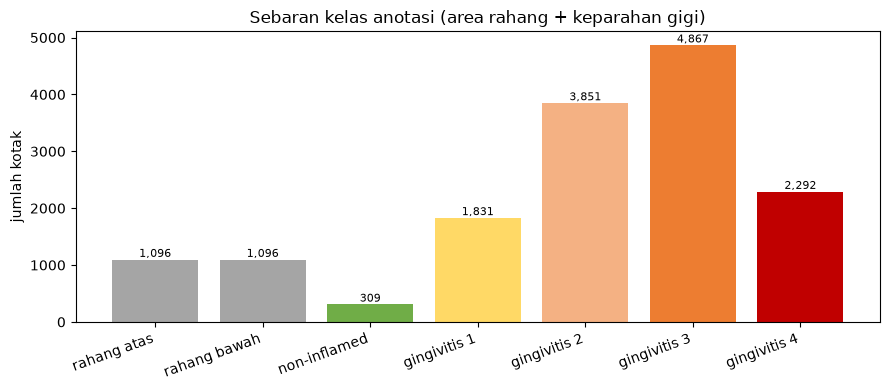

In [4]:
# ============ Sebaran kelas anotasi ============
cnt = collections.Counter()
for r in REKAM:
    for c, *_ in r['jaw'] + r['gigi']: cnt[c] += 1
ks = sorted(cnt)
warna = ['#A5A5A5','#A5A5A5','#70AD47','#FFD966','#F4B183','#ED7D31','#C00000']
plt.figure(figsize=(9, 4))
plt.bar([NAMA_KELAS[k] for k in ks], [cnt[k] for k in ks], color=[warna[k] for k in ks])
for i, k in enumerate(ks): plt.text(i, cnt[k], f'{cnt[k]:,}', ha='center', va='bottom', fontsize=8)
plt.ylabel('jumlah kotak'); plt.xticks(rotation=20, ha='right')
plt.title('Sebaran kelas anotasi (area rahang + keparahan gigi)')
plt.tight_layout(); simpan('01_sebaran_kelas.png'); plt.show()

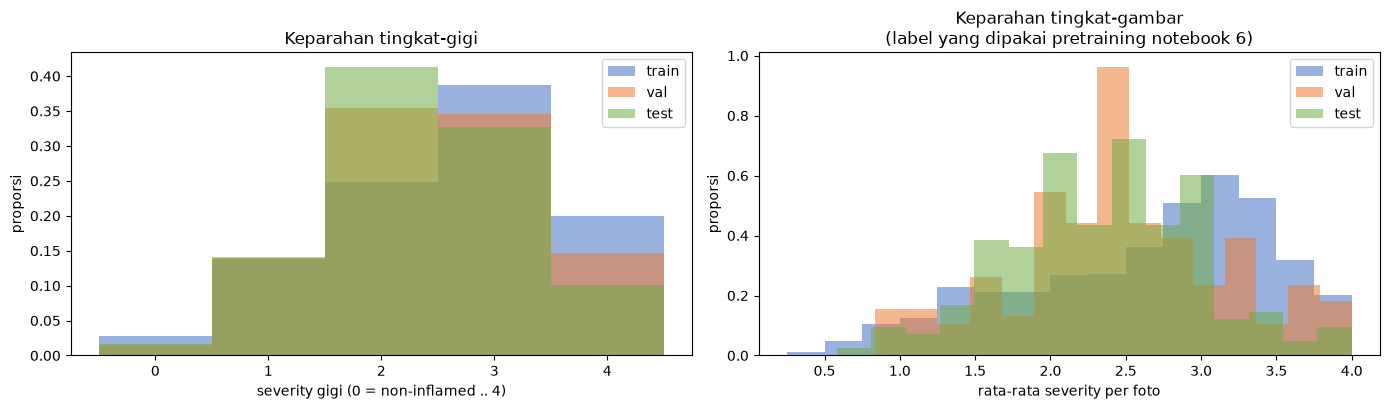

In [5]:
# ============ Keparahan: tingkat-gigi & tingkat-gambar ============
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
cor = {'train':'#4472C4', 'val':'#ED7D31', 'test':'#70AD47'}
for tag, c in cor.items():
    s = [k - 2 for r in REKAM if r['split']==tag for k, *_ in r['gigi']]
    ax[0].hist(s, bins=np.arange(-0.5, 5.5), alpha=.55, label=tag, color=c, density=True)
ax[0].set_xticks(range(5)); ax[0].set_xlabel('severity gigi (0 = non-inflamed .. 4)')
ax[0].set_ylabel('proporsi'); ax[0].set_title('Keparahan tingkat-gigi'); ax[0].legend()
for tag, c in cor.items():
    m = [r['sev_mean'] for r in REKAM if r['split']==tag]
    ax[1].hist(m, bins=15, alpha=.55, label=tag, color=c, density=True)
ax[1].set_xlabel('rata-rata severity per foto'); ax[1].set_ylabel('proporsi')
ax[1].set_title('Keparahan tingkat-gambar\n(label yang dipakai pretraining notebook 6)'); ax[1].legend()
plt.tight_layout(); simpan('02_severity.png'); plt.show()

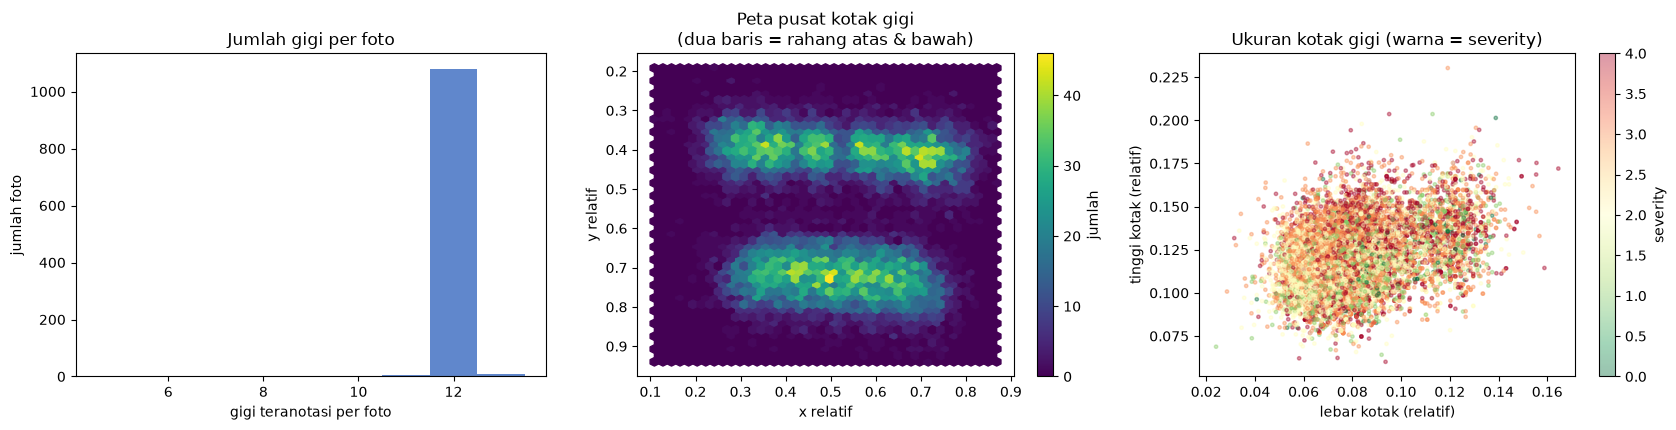

In [6]:
# ============ Gigi per foto & geometri kotak ============
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
ax[0].hist(ng, bins=np.arange(ng.min()-.5, ng.max()+1.5), color='#4472C4', alpha=.85)
ax[0].set_xlabel('gigi teranotasi per foto'); ax[0].set_ylabel('jumlah foto')
ax[0].set_title('Jumlah gigi per foto')

xs = np.array([x for r in REKAM for _, x, y, w, h in r['gigi']])
ys = np.array([y for r in REKAM for _, x, y, w, h in r['gigi']])
ws = np.array([w for r in REKAM for _, x, y, w, h in r['gigi']])
hs = np.array([h for r in REKAM for _, x, y, w, h in r['gigi']])
sv = np.array([c-2 for r in REKAM for c, x, y, w, h in r['gigi']])
hb = ax[1].hexbin(xs, ys, gridsize=40, cmap='viridis'); ax[1].invert_yaxis()
ax[1].set_title('Peta pusat kotak gigi\n(dua baris = rahang atas & bawah)')
ax[1].set_xlabel('x relatif'); ax[1].set_ylabel('y relatif'); fig.colorbar(hb, ax=ax[1], label='jumlah')
sc = ax[2].scatter(ws, hs, c=sv, cmap='RdYlGn_r', s=6, alpha=.4)
ax[2].set_xlabel('lebar kotak (relatif)'); ax[2].set_ylabel('tinggi kotak (relatif)')
ax[2].set_title('Ukuran kotak gigi (warna = severity)'); fig.colorbar(sc, ax=ax[2], label='severity')
plt.tight_layout(); simpan('03_geometri_kotak.png'); plt.show()

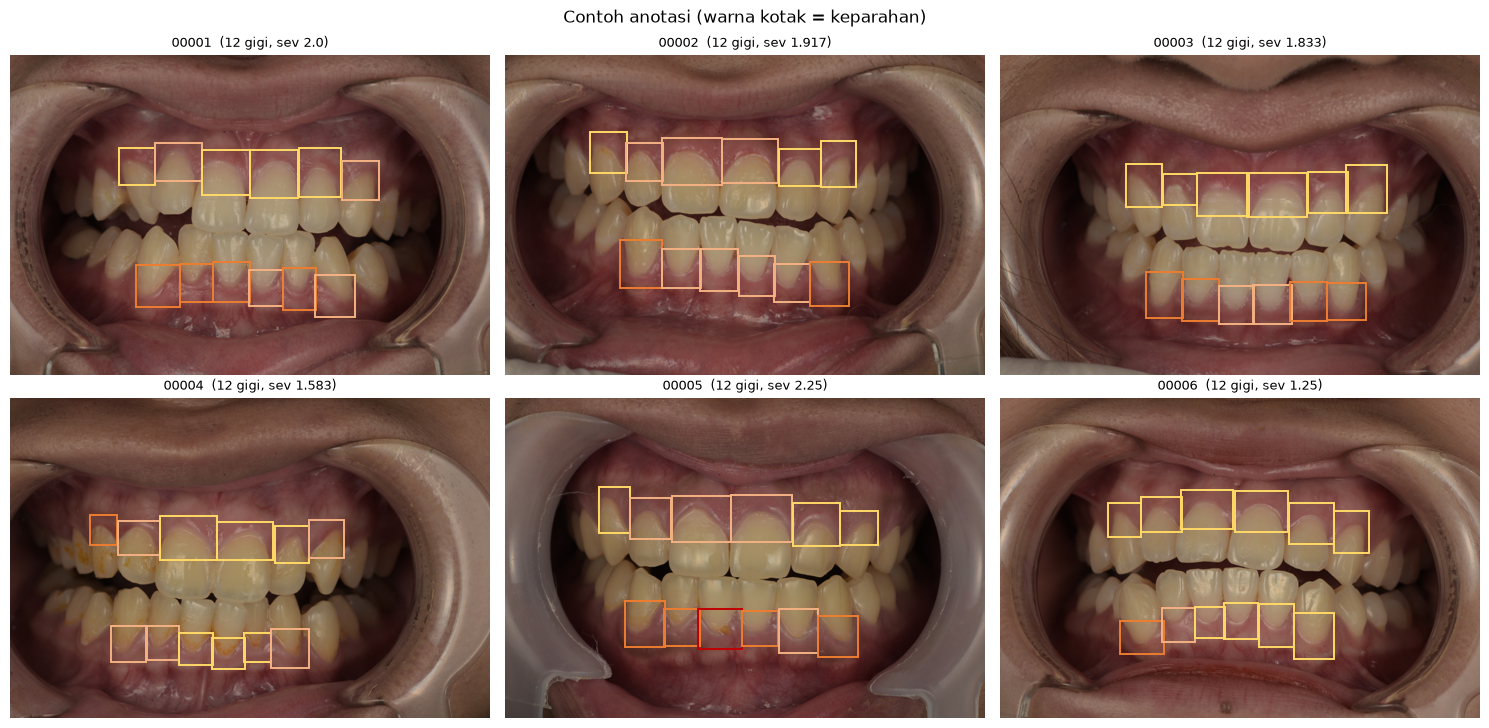

In [7]:
# ============ Contoh foto beserta anotasi kotak ============
import matplotlib.patches as patches
WARNA_K = {0:'#3366ff', 1:'#3366ff', 2:'#70AD47', 3:'#FFD966', 4:'#F4B183', 5:'#ED7D31', 6:'#C00000'}
samp = [r for r in REKAM if r['split']=='train'][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for r, axx in zip(samp, axes.ravel()):
    img = Image.open(os.path.join(GINGIVITIS_DIR, r['folder'], 'Images',
                                  r['file'].replace('.txt', '.jpg'))).convert('RGB')
    W, H = img.size
    img.thumbnail((480, 480)); w2, h2 = img.size
    axx.imshow(img); axx.axis('off')
    axx.set_title(f"{r['file'].replace('.txt','')}  ({r['n_gigi']} gigi, sev {r['sev_mean']})", fontsize=9)
    for c, x, y, w, h in r['gigi']:
        axx.add_patch(patches.Rectangle(((x-w/2)*w2, (y-h/2)*h2), w*w2, h*h2,
                      fill=False, edgecolor=WARNA_K[c], lw=1.4))
fig.suptitle('Contoh anotasi (warna kotak = keparahan)', fontsize=12)
plt.tight_layout(); simpan('04_contoh_anotasi.png'); plt.show()

Kosakata keparahan pada caption: {'gingivitis 1': 1642, 'gingivitis 2': 3418, 'gingivitis 3': 3927, 'gingivitis 4': 2045, 'non-inflamed': 335}


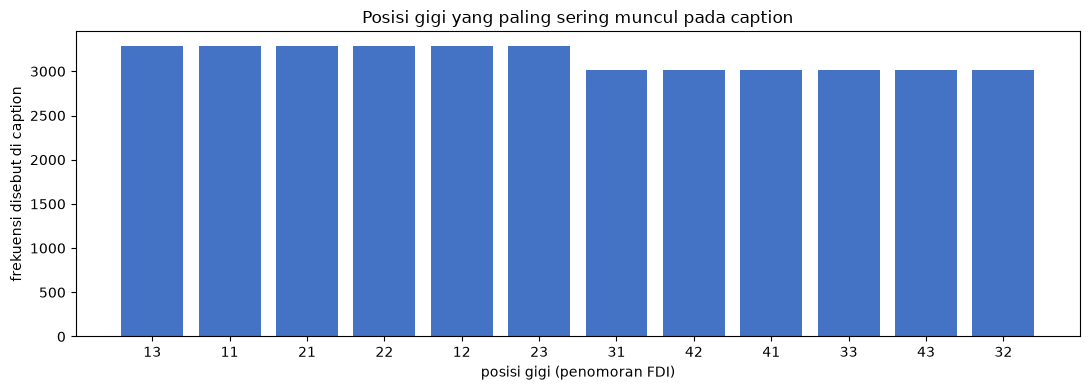

In [8]:
# ============ Analisis caption ============
def gabung_caption(folder):
    teks = []
    for f in glob.glob(os.path.join(GINGIVITIS_DIR, folder, '*aptions*.csv')):
        for row in csv.reader(open(f, encoding='utf-8-sig')):
            teks.append(' '.join(row))
    return ' '.join(teks)

semua = ' '.join(gabung_caption(folder) for folder, _ in SPLITS)
posisi = collections.Counter(re.findall(r'\b([1-4][1-8])\b', semua))     # penomoran gigi FDI
kosakata = collections.Counter(re.findall(r'gingivitis \d|non-inflamed', semua))
print('Kosakata keparahan pada caption:', dict(sorted(kosakata.items())))

top = posisi.most_common(16)
plt.figure(figsize=(11, 4))
plt.bar([p for p, _ in top], [n for _, n in top], color='#4472C4')
plt.xlabel('posisi gigi (penomoran FDI)'); plt.ylabel('frekuensi disebut di caption')
plt.title('Posisi gigi yang paling sering muncul pada caption')
plt.tight_layout(); simpan('05_caption_fdi.png'); plt.show()

## Ringkasan

- **1.096 foto intraoral resolusi tinggi** (~7286×4863), terbagi 732 / 182 / 182.
- **~12 gigi anterior teranotasi per foto** — tampilan frontal, sejenis dengan data IOTN-AC.
- Keparahan **timpang** ke tingkat sedang–berat; kelas non-inflamed paling jarang.
- Peta pusat kotak membentuk **dua baris lengkung** (rahang atas & bawah) yang konsisten.
- Caption memakai penomoran gigi **FDI** dan kosakata keparahan yang terbatas dan teratur.

**Relevansi untuk IOTN-AC.** Modalitasnya sama (foto frontal intraoral berwarna), sehingga
dataset ini cocok untuk **domain pretraining backbone** (notebook 6). Namun labelnya menilai
**gusi**, bukan susunan gigi — jadi ia mengadaptasi backbone ke domain foto intraoral, bukan
mengajari geometri alignment yang menentukan skor AC.